# Week 3: Deep Learning and Neural Network Basics
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**📋 Learning Objectives:**
1. Explain the architecture of a feedforward neural network (Understand)
2. Describe the roles of activation functions, loss functions, and optimizers (Understand)
3. Build and train a neural network using Keras in Colab (Apply)
4. Interpret training curves and diagnose overfitting vs underfitting (Analyze)

**🛠 Tools:** Google Colab + Gemini AI
**📁 Dataset:** Pima Indians Diabetes (768 patients, 8 features)
**⏱ Estimated Time:** 40–50 minutes

---

**🏥 Clinical Scenario:** A pathologist at NCKU Hospital reviews 200 tissue slides per day. By slide #180, fatigue sets in and subtle cancerous cells are missed. Today we build the foundation of the AI that could pre-screen those slides — a neural network, layer by layer.

## 0. Environment Setup

All core libraries are pre-installed in Google Colab. We install nothing extra — just import and go!

In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Comparison baselines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries loaded successfully!
NumPy: 2.0.2
TensorFlow: 2.19.0
Keras: 3.10.0
GPU available: []


---
## 1. A Single Neuron in NumPy

**📍 Slide Reference:** Lab 1, Slide 21

Before using any framework, let's build the **fundamental computation** of a neural network by hand: one neuron that takes 3 cell features, multiplies by weights, adds a bias, and passes through a sigmoid activation.

**Clinical framing:** This single neuron answers ONE question: "Given these 3 cell measurements, is this tissue suspicious?"

In [2]:
# ============================================================
# Section 1: A Single Neuron in NumPy
# ============================================================

def sigmoid(z):
    """Sigmoid activation: squash any value to (0, 1)."""
    return 1 / (1 + np.exp(-z))

# --- Single neuron: 3 inputs (cell features) ---
x = np.array([0.8, 0.3, 0.5])   # cell radius, texture, symmetry
w = np.array([0.6, -0.2, 0.4])  # learned weights (importance of each feature)
b = 0.1                          # bias

# Forward pass (this IS the fundamental computation)
z = np.dot(w, x) + b            # weighted sum
a = sigmoid(z)                   # activation

print("=" * 50)
print("🧠 Single Neuron Forward Pass")
print("=" * 50)
print(f"Inputs (x):  {x}")
print(f"Weights (w): {w}")
print(f"Bias (b):    {b}")
print(f"")
print(f"Step 1: z = w·x + b = {w[0]}*{x[0]} + {w[1]}*{x[1]} + {w[2]}*{x[2]} + {b}")
print(f"         z = {z:.4f}")
print(f"Step 2: a = sigmoid({z:.4f}) = {a:.4f}")
print(f"")
print(f"🏥 Interpretation: {a*100:.1f}% probability of suspicious tissue")
print(f"   {'Flagged for review ⚠️' if a > 0.5 else 'Likely normal ✅'}")

🧠 Single Neuron Forward Pass
Inputs (x):  [0.8 0.3 0.5]
Weights (w): [ 0.6 -0.2  0.4]
Bias (b):    0.1

Step 1: z = w·x + b = 0.6*0.8 + -0.2*0.3 + 0.4*0.5 + 0.1
         z = 0.7200
Step 2: a = sigmoid(0.7200) = 0.6726

🏥 Interpretation: 67.3% probability of suspicious tissue
   Flagged for review ⚠️


In [3]:
# --- Experiment: What happens when we change inputs? ---
print("\n🔬 Experiment: How does the neuron respond to different inputs?\n")
test_inputs = [
    ([0.1, 0.1, 0.1], "Small, regular cells"),
    ([0.5, 0.5, 0.5], "Medium cells"),
    ([0.9, 0.8, 0.9], "Large, irregular cells"),
    ([0.0, 0.0, 0.0], "Zero input (baseline)"),
]

for inputs, label in test_inputs:
    x_test = np.array(inputs)
    z_test = np.dot(w, x_test) + b
    a_test = sigmoid(z_test)
    flag = "⚠️" if a_test > 0.5 else "✅"
    print(f"  {label:25s} → z={z_test:.3f}, output={a_test:.3f} ({a_test*100:.1f}%) {flag}")

print("\n💡 Notice: larger/more irregular cells → higher suspicion score.")
print("   The weights encode what the neuron considers important.")


🔬 Experiment: How does the neuron respond to different inputs?

  Small, regular cells      → z=0.180, output=0.545 (54.5%) ⚠️
  Medium cells              → z=0.500, output=0.622 (62.2%) ⚠️
  Large, irregular cells    → z=0.840, output=0.698 (69.8%) ⚠️
  Zero input (baseline)     → z=0.100, output=0.525 (52.5%) ⚠️

💡 Notice: larger/more irregular cells → higher suspicion score.
   The weights encode what the neuron considers important.


---
## 2. The Same Neuron in Keras

**📍 Slide Reference:** Lab 1, Slide 22

Now let's build the **exact same neuron** using Keras. What took us ~10 lines in NumPy takes **3 lines** in Keras. The framework handles the math; you focus on architecture.

In [4]:
# ============================================================
# Section 2: The Same Neuron in Keras
# ============================================================

# Build a single neuron with Keras (3 lines!)
model_single = Sequential([
    Dense(1, activation='sigmoid', input_shape=(3,))
])

# Same input as our NumPy neuron
x_keras = np.array([[0.8, 0.3, 0.5]])  # Note: Keras expects 2D input (batch, features)
pred = model_single.predict(x_keras, verbose=0)

print("=" * 50)
print("🤖 Keras Single Neuron")
print("=" * 50)
print(f"Input:  {x_keras[0]}")
print(f"Output: {pred[0,0]:.4f}")
print(f"")
print(f"NumPy neuron output:  {a:.4f}")
print(f"Keras neuron output:  {pred[0,0]:.4f}")
print(f"")
print("⚠️ Outputs differ because Keras initializes RANDOM weights.")
print("   After training on data, both would converge to similar values.")

🤖 Keras Single Neuron
Input:  [0.8 0.3 0.5]
Output: 0.2817

NumPy neuron output:  0.6726
Keras neuron output:  0.2817

⚠️ Outputs differ because Keras initializes RANDOM weights.
   After training on data, both would converge to similar values.


In [5]:
# Let's peek inside the Keras neuron
weights, bias = model_single.layers[0].get_weights()
print("\n🔍 Inside the Keras neuron:")
print(f"   Weights: {weights.flatten()}")
print(f"   Bias:    {bias[0]:.4f}")
print(f"")
print(f"   Our NumPy weights: {w}")
print(f"   Our NumPy bias:    {b}")

# Verify: manually compute Keras output
z_verify = np.dot(weights.flatten(), x_keras[0]) + bias[0]
a_verify = sigmoid(z_verify)
print(f"\n   Manual verification: sigmoid({z_verify:.4f}) = {a_verify:.4f}")
print(f"   Keras output:        {pred[0,0]:.4f}")
print(f"   Match: {np.isclose(a_verify, pred[0,0], atol=1e-5)} ✅")

print("\n💡 NumPy = understanding the math. Keras = building real systems.")
print("   Same computation, different abstraction level.")


🔍 Inside the Keras neuron:
   Weights: [-0.59339994 -0.61745125 -0.552058  ]
   Bias:    0.0000

   Our NumPy weights: [ 0.6 -0.2  0.4]
   Our NumPy bias:    0.1

   Manual verification: sigmoid(-0.9360) = 0.2817
   Keras output:        0.2817
   Match: True ✅

💡 NumPy = understanding the math. Keras = building real systems.
   Same computation, different abstraction level.


---
## 3. Visualize Activation Functions

**📍 Slide Reference:** Lab 1, Slide 23

Activation functions introduce **non-linearity** — without them, stacking layers would be useless (just one big linear transformation). Let's visualize the four most important ones.

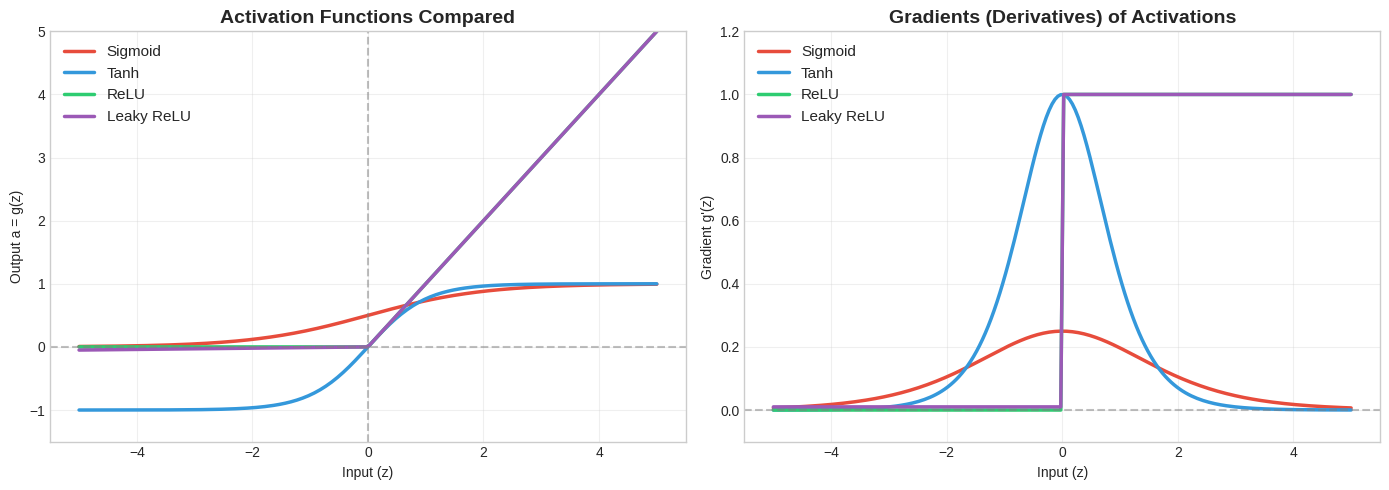

💡 Key observations:
   • Sigmoid/Tanh: gradients → 0 at extremes (VANISHING GRADIENT)
   • ReLU: gradient = 1 for positive inputs (fast training!)
   • ReLU: gradient = 0 for negative inputs (DYING ReLU problem)
   • Leaky ReLU: small gradient for negatives (fixes dying ReLU)


In [6]:
# ============================================================
# Section 3: Visualize Activation Functions
# ============================================================

x_range = np.linspace(-5, 5, 200)

# Define activation functions
activations = {
    'Sigmoid': 1 / (1 + np.exp(-x_range)),
    'Tanh': np.tanh(x_range),
    'ReLU': np.maximum(0, x_range),
    'Leaky ReLU': np.where(x_range > 0, x_range, 0.01 * x_range),
}

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All activations together
ax = axes[0]
for (name, values), color in zip(activations.items(), colors):
    ax.plot(x_range, values, label=name, linewidth=2.5, color=color)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Activation Functions Compared', fontsize=14, fontweight='bold')
ax.set_xlabel('Input (z)'); ax.set_ylabel('Output a = g(z)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 5)

# Plot 2: Gradients (derivatives)
ax = axes[1]
gradients = {
    'Sigmoid': activations['Sigmoid'] * (1 - activations['Sigmoid']),
    'Tanh': 1 - np.tanh(x_range)**2,
    'ReLU': np.where(x_range > 0, 1.0, 0.0),
    'Leaky ReLU': np.where(x_range > 0, 1.0, 0.01),
}
for (name, values), color in zip(gradients.items(), colors):
    ax.plot(x_range, values, label=name, linewidth=2.5, color=color)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Gradients (Derivatives) of Activations', fontsize=14, fontweight='bold')
ax.set_xlabel('Input (z)'); ax.set_ylabel("Gradient g'(z)")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.2)

plt.tight_layout()
plt.show()

print("💡 Key observations:")
print("   • Sigmoid/Tanh: gradients → 0 at extremes (VANISHING GRADIENT)")
print("   • ReLU: gradient = 1 for positive inputs (fast training!)")
print("   • ReLU: gradient = 0 for negative inputs (DYING ReLU problem)")
print("   • Leaky ReLU: small gradient for negatives (fixes dying ReLU)")

In [7]:
# --- Interactive: Softmax for multi-class ---
print("\n🎯 Softmax: Choosing between diagnoses")
print("=" * 50)

# Simulate raw network outputs for 3 classes
raw_scores = np.array([2.1, 0.8, -0.5])
softmax_probs = np.exp(raw_scores) / np.sum(np.exp(raw_scores))

classes = ['Malignant', 'Benign', 'Atypical']
print(f"Raw scores: {raw_scores}")
print(f"Softmax:    {softmax_probs.round(3)}")
print(f"Sum:        {softmax_probs.sum():.4f} (always = 1.0)")
print()
for cls, prob in zip(classes, softmax_probs):
    bar = '█' * int(prob * 40)
    print(f"  {cls:12s}: {prob:.1%} {bar}")
print(f"\n🏥 Diagnosis: {classes[np.argmax(softmax_probs)]} ({softmax_probs.max():.1%} confidence)")


🎯 Softmax: Choosing between diagnoses
Raw scores: [ 2.1  0.8 -0.5]
Softmax:    [0.742 0.202 0.055]
Sum:        1.0000 (always = 1.0)

  Malignant   : 74.2% █████████████████████████████
  Benign      : 20.2% ████████
  Atypical    : 5.5% ██

🏥 Diagnosis: Malignant (74.2% confidence)


---
## 4. Load & Preprocess Pima Diabetes Dataset

**📍 Slide Reference:** Lab 2, Slide 43

Now we move from toy examples to **real patient data**. The Pima Indians Diabetes dataset has 768 patients with 8 features (glucose, BMI, age, etc.) and a binary outcome (diabetes yes/no).

**⚠️ Data quality issue:** Several features use `0` as a placeholder for missing values (e.g., glucose=0 is biologically impossible). We must fix this before training.

In [8]:
# ============================================================
# Section 4: Load & Preprocess Pima Diabetes
# ============================================================

# Load dataset (with synthetic fallback)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['Pregnancies', 'Glucose', 'BP', 'SkinThick', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']

try:
    df = pd.read_csv(url, names=cols)
    print("✅ Pima dataset loaded from URL")
except Exception as e:
    print(f"⚠️ Could not load URL: {e}")
    print("   Generating synthetic fallback...")
    from sklearn.datasets import make_classification
    X_syn, y_syn = make_classification(n_samples=768, n_features=8, random_state=42)
    df = pd.DataFrame(X_syn, columns=cols[:-1])
    df['Outcome'] = (y_syn > 0).astype(int)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"   → {df.shape[0]} patients, {df.shape[1]-1} features + 1 target")
print(f"\n🏥 Class distribution:")
print(f"   No diabetes (0): {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")
print(f"   Diabetes (1):    {(df['Outcome']==1).sum()} ({(df['Outcome']==1).mean()*100:.1f}%)")
display(df.head())

✅ Pima dataset loaded from URL

📊 Dataset shape: (768, 9)
   → 768 patients, 8 features + 1 target

🏥 Class distribution:
   No diabetes (0): 500 (65.1%)
   Diabetes (1):    268 (34.9%)


,Pregnancies,Glucose,BP,SkinThick,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# --- Handle impossible zero values ---
print("🔍 Checking for impossible zero values:")
zero_cols = ['Glucose', 'BP', 'SkinThick', 'Insulin', 'BMI']
for c in zero_cols:
    n_zeros = (df[c] == 0).sum()
    if n_zeros > 0:
        print(f"   {c:12s}: {n_zeros:3d} zeros ({n_zeros/len(df)*100:.1f}%) → replacing with NaN")
        df[c] = df[c].replace(0, np.nan)

# Fill NaN with median (robust to outliers)
df = df.fillna(df.median())
print(f"\n✅ Missing values filled with column medians.")
print(f"   Remaining NaN: {df.isna().sum().sum()}")

🔍 Checking for impossible zero values:
   Glucose     :   5 zeros (0.7%) → replacing with NaN
   BP          :  35 zeros (4.6%) → replacing with NaN
   SkinThick   : 227 zeros (29.6%) → replacing with NaN
   Insulin     : 374 zeros (48.7%) → replacing with NaN
   BMI         :  11 zeros (1.4%) → replacing with NaN

✅ Missing values filled with column medians.
   Remaining NaN: 0


In [10]:
# --- Split into train / validation / test (60/20/20) ---
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features (fit on train only!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"📦 Data splits:")
print(f"   Train:      {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Validation: {X_val.shape[0]} patients ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"   Test:       {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features:   {X_train.shape[1]}")
print(f"\n✅ StandardScaler fit on train, applied to val+test (no data leakage!)")

📦 Data splits:
   Train:      460 patients (60%)
   Validation: 154 patients (20%)
   Test:       154 patients (20%)
   Features:   8

✅ StandardScaler fit on train, applied to val+test (no data leakage!)


---
## 5. Build & Train a 3-Layer MLP

**📍 Slide Reference:** Lab 2, Slides 44–45

Now we build our first **real neural network**: a 3-layer MLP (Multi-Layer Perceptron) with Dropout regularization.

Architecture: `Input(8) → Dense(32, ReLU) → Dropout(0.3) → Dense(16, ReLU) → Dense(1, Sigmoid)`

In [11]:
# ============================================================
# Section 5a: Build the Model
# ============================================================

model = Sequential([
    Dense(32, activation='relu', input_shape=(8,)),   # 8 features → 32 neurons
    Dropout(0.3),                                      # prevent overfitting
    Dense(16, activation='relu'),                      # 32 → 16 neurons
    Dense(1, activation='sigmoid')                     # 16 → 1 probability
])

model.summary()

print("\n💡 Parameter breakdown:")
print(f"   Layer 1 (Dense 32): 8×32 + 32 bias = {8*32+32} params")
print(f"   Dropout:            0 params (just a mask)")
print(f"   Layer 2 (Dense 16): 32×16 + 16 bias = {32*16+16} params")
print(f"   Output (Dense 1):   16×1 + 1 bias = {16*1+1} params")
print(f"   Total:              {8*32+32 + 32*16+16 + 16+1} params")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)


💡 Parameter breakdown:
   Layer 1 (Dense 32): 8×32 + 32 bias = 288 params
   Dropout:            0 params (just a mask)
   Layer 2 (Dense 16): 32×16 + 16 bias = 528 params
   Output (Dense 1):   16×1 + 1 bias = 17 params
   Total:              833 params


In [12]:
# ============================================================
# Section 5b: Compile and Train
# ============================================================

model.compile(
    optimizer='adam',                    # adaptive learning rate
    loss='binary_crossentropy',          # binary classification
    metrics=['accuracy']                 # track accuracy too
)

early_stop = EarlyStopping(
    monitor='val_loss',                  # watch validation loss
    patience=10,                         # stop if no improvement for 10 epochs
    restore_best_weights=True            # go back to best epoch
)

print("🏋️ Training the neural network...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"   Stopped at epoch: {len(history.history['loss'])}")
print(f"   Best val_loss: {min(history.history['val_loss']):.4f}")

🏋️ Training the neural network...

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4933 - loss: 0.7971 - val_accuracy: 0.5714 - val_loss: 0.6944
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5540 - loss: 0.7163 - val_accuracy: 0.6818 - val_loss: 0.6242
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6771 - loss: 0.6413 - val_accuracy: 0.7273 - val_loss: 0.5711
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7221 - loss: 0.5765 - val_accuracy: 0.7857 - val_loss: 0.5306
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6938 - loss: 0.5724 - val_accuracy: 0.7922 - val_loss: 0.5026
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7429 - loss: 0.5311 - val_accuracy: 0.7662 - val_loss: 0.4792
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7317 - loss: 0.5057 - val_accuracy: 0.7727 - val_loss: 0.4639
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7534 - 

In [13]:
# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_proba = model.predict(X_test, verbose=0).flatten()
y_pred_nn = (y_pred_proba >= 0.5).astype(int)

print(f"\n🎯 Test Set Results:")
print(f"   Loss:     {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"   AUC-ROC:  {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['No Diabetes', 'Diabetes']))


🎯 Test Set Results:
   Loss:     0.5266
   Accuracy: 0.7403 (74.0%)
   AUC-ROC:  0.7839

📊 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.77      0.85      0.81       101
    Diabetes       0.65      0.53      0.58        53

    accuracy                           0.74       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



---
## 6. Plot Training Curves

**📍 Slide Reference:** Lab 2, Slide 46

Training curves are your **diagnostic tool** for neural networks. They tell you whether the model is:
- **Underfitting**: both losses are high → model too simple
- **Overfitting**: train loss low but val loss rising → model memorizing
- **Just right**: both losses converge with small gap → sweet spot ✅

**This is a CRITICAL skill — you'll use it every week from now on.**

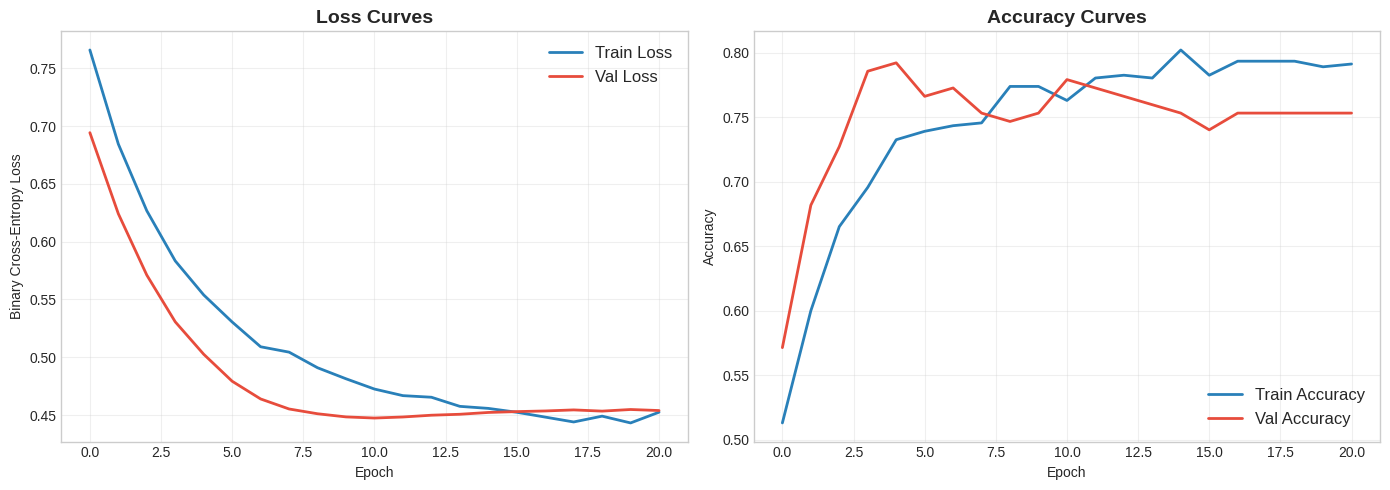

🔍 Training Curve Diagnosis:
   Final train loss: 0.4524
   Final val loss:   0.4539
   Gap:              0.0014
   ✅ Looks good! Both losses are low with a reasonable gap.


In [14]:
# ============================================================
# Section 6: Plot Training Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history.history['loss'], label='Train Loss', color='#2980B9', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#E74C3C', linewidth=2)
ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.legend(fontsize=12); ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='#2980B9', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='#E74C3C', linewidth=2)
ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=12); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnose
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print("🔍 Training Curve Diagnosis:")
print(f"   Final train loss: {final_train_loss:.4f}")
print(f"   Final val loss:   {final_val_loss:.4f}")
print(f"   Gap:              {gap:.4f}")

if gap > 0.15:
    print("   ⚠️ Possible OVERFITTING: val loss significantly higher than train loss.")
    print("   → Try: more Dropout, less neurons, or more data.")
elif final_train_loss > 0.5:
    print("   ⚠️ Possible UNDERFITTING: both losses are still high.")
    print("   → Try: more neurons, more layers, or train longer.")
else:
    print("   ✅ Looks good! Both losses are low with a reasonable gap.")

---
## 7. 📝 Student Tasks

**📍 Slide Reference:** Lab 2, Slide 47

Complete the following tasks to deepen your understanding. Each one teaches a different lesson about neural network behavior.

| Task | Description | Difficulty |
|------|-------------|------------|
| 1 | Change hidden units (32→64) — does accuracy improve? | ⭐ |
| 2 | Remove Dropout — watch overfitting happen on training curves | ⭐ |
| 3 | Add BatchNormalization — compare training speed | ⭐⭐ |
| 4 | Try SGD vs Adam — plot both learning curves | ⭐⭐ |
| 5 | Compare NN vs LogReg vs RF on same test set | ⭐⭐⭐ |

In [15]:
# ============================================================
# Task 1 (⭐): Change hidden units (32→64)
# ============================================================
# TODO: Build a new model with 64 hidden units instead of 32.
#       Train it and compare accuracy with the original model.
#
# Hint: Change Dense(32, ...) to Dense(64, ...)
# Question: Does doubling neurons always improve performance?

# model_64 = Sequential([
#     Dense(64, activation='relu', input_shape=(8,)),
#     Dropout(0.3),
#     Dense(16, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# model_64.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# history_64 = model_64.fit(X_train, y_train, validation_data=(X_val, y_val),
#                           epochs=100, batch_size=32,
#                           callbacks=[EarlyStopping(monitor='val_loss', patience=10,
#                                                    restore_best_weights=True)], verbose=0)
# _, acc_64 = model_64.evaluate(X_test, y_test, verbose=0)
# print(f"Original (32 units): {test_acc:.4f}")
# print(f"Modified (64 units): {acc_64:.4f}")

print("\n📝 Uncomment the code above and run to complete Task 1")


📝 Uncomment the code above and run to complete Task 1


In [16]:
# ============================================================
# Task 2 (⭐): Remove Dropout
# ============================================================
# TODO: Build a model WITHOUT Dropout and compare training curves.
#       Look for the overfitting gap (train loss << val loss).
#
# Hint: Simply remove the Dropout(0.3) layer.
# Expected: train accuracy ↑ but val accuracy may ↓

# model_no_drop = Sequential([
#     Dense(32, activation='relu', input_shape=(8,)),
#     Dense(16, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# model_no_drop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# history_nd = model_no_drop.fit(X_train, y_train, validation_data=(X_val, y_val),
#                                epochs=100, batch_size=32, verbose=0)
#
# # Plot and compare
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(history_nd.history['loss'], label='Train (no dropout)', color='#2980B9')
# ax.plot(history_nd.history['val_loss'], label='Val (no dropout)', color='#E74C3C')
# ax.set_title('Without Dropout: Watch for Overfitting!', fontweight='bold')
# ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
# plt.show()

print("\n📝 Uncomment the code above and run to complete Task 2")


📝 Uncomment the code above and run to complete Task 2


In [17]:
# ============================================================
# Task 3 (⭐⭐): Add BatchNormalization
# ============================================================
# TODO: Add BatchNormalization layers. Compare training speed
#       (how many epochs to converge) with the original model.
#
# Correct layer order: Dense → BatchNorm → Activation → Dropout
# Note: When using BatchNorm, don't set activation in Dense();
#       use a separate Activation layer instead.

# from tensorflow.keras.layers import Activation
#
# model_bn = Sequential([
#     Dense(32, input_shape=(8,)),
#     BatchNormalization(),
#     Activation('relu'),
#     Dropout(0.3),
#     Dense(16),
#     BatchNormalization(),
#     Activation('relu'),
#     Dense(1, activation='sigmoid')
# ])
# model_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# history_bn = model_bn.fit(X_train, y_train, validation_data=(X_val, y_val),
#                           epochs=100, batch_size=32,
#                           callbacks=[EarlyStopping(monitor='val_loss', patience=10,
#                                                    restore_best_weights=True)], verbose=0)
# print(f"Epochs with BatchNorm: {len(history_bn.history['loss'])}")
# print(f"Epochs without:        {len(history.history['loss'])}")

print("\n📝 Uncomment the code above and run to complete Task 3")


📝 Uncomment the code above and run to complete Task 3


In [18]:
# ============================================================
# Task 4 (⭐⭐): SGD vs Adam
# ============================================================
# TODO: Train two identical models — one with SGD, one with Adam.
#       Plot both learning curves on the same figure.
#
# Hint: model.compile(optimizer='sgd', ...) vs optimizer='adam'
# Expected: Adam converges faster, SGD may be noisier

# def build_model():
#     return Sequential([
#         Dense(32, activation='relu', input_shape=(8,)),
#         Dropout(0.3),
#         Dense(16, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])
#
# model_sgd = build_model()
# model_sgd.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
# h_sgd = model_sgd.fit(X_train, y_train, validation_data=(X_val, y_val),
#                       epochs=100, batch_size=32, verbose=0)
#
# model_adam = build_model()
# model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# h_adam = model_adam.fit(X_train, y_train, validation_data=(X_val, y_val),
#                        epochs=100, batch_size=32, verbose=0)
#
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(h_sgd.history['val_loss'], label='SGD (val)', color='#E74C3C', linewidth=2)
# ax.plot(h_adam.history['val_loss'], label='Adam (val)', color='#2980B9', linewidth=2)
# ax.set_title('SGD vs Adam: Validation Loss', fontweight='bold')
# ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(fontsize=12)
# plt.show()

print("\n📝 Uncomment the code above and run to complete Task 4")


📝 Uncomment the code above and run to complete Task 4


---
## 8. 🤖 Gemini AI Exercise

**📍 Slide Reference:** Lab 2, Slide 48

Use Gemini to help you **debug**, **explain**, and **improve** your neural network. This teaches you how AI assistants can accelerate your learning — but YOU must interpret clinically.

> **Note:** `google.colab.ai` is only available in the Colab environment.

In [19]:
# ============================================================
# Section 8: Gemini AI Exercise
# ============================================================

try:
    from google.colab import ai

    # Prompt 1: Debug overfitting
    print("🤖 Gemini Prompt 1: Debug overfitting")
    print("=" * 50)
    response = ai.generate_text(
        "I built a 3-layer neural network (32→16→1) for diabetes prediction "
        "on the Pima dataset. Accuracy is 77% but training curves show the "
        "validation loss starts rising after epoch 30. Explain what's happening "
        "and suggest 3 solutions."
    )
    print(response)

except ImportError:
    print("⚠️ google.colab.ai is not available in this environment.")
    print("   This section works only in Google Colab.")
    print("\n📝 Try these prompts manually in Colab's Gemini sidebar:")
    print("")
    print('   Prompt 1: "I built a 3-layer neural network (32→16→1) for diabetes')
    print('   prediction. Val loss starts rising after epoch 30. Explain and fix."')
    print("")
    print('   Prompt 2: "Write Keras code to add BatchNormalization and Dropout.')
    print('   Explain the correct layer ordering and why it matters."')
    print("")
    print('   Prompt 3: "Compare neural networks vs logistic regression for a small')
    print('   tabular medical dataset (768 samples). When would you choose each?"')

🤖 Gemini Prompt 1: Debug overfitting
It sounds like you're dealing with a classic case of **overfitting**.

Let's break down what's happening:

### What's Happening: Overfitting

1.  **Initial Learning (Epochs 1-30):** During the initial epochs, your neural network is learning the general patterns and relationships within your training data that are relevant for predicting diabetes. Both your training loss and validation loss are decreasing, indicating that the model is improving its ability to make correct predictions on both seen and unseen data.

2.  **The Turning Point (After Epoch 30):**
    *   **Training Loss Continues to Decrease:** Your model continues to learn, becoming increasingly specialized to the *specific examples* in your training dataset. It starts memorizing noise, outliers, and idiosyncratic patterns unique to the training set. This drives the training loss lower and lower.
    *   **Validation Loss Starts Rising:** Because the model is learning these specific, non-

In [20]:
try:
    from google.colab import ai

    # Prompt 2: Layer ordering
    print("\n🤖 Gemini Prompt 2: Layer ordering")
    print("=" * 50)
    response = ai.generate_text(
        "Write Keras code to add BatchNormalization and Dropout to an existing "
        "Sequential model. Explain the correct layer ordering and why it matters."
    )
    print(response)

except ImportError:
    print("💡 Layer ordering best practice (from lecture Slide 38):")
    print("   1. Dense / Conv layer (computation)")
    print("   2. BatchNormalization (normalize raw output)")
    print("   3. Activation (e.g., ReLU)")
    print("   4. Dropout (regularize activated output)")


🤖 Gemini Prompt 2: Layer ordering
Adding BatchNormalization and Dropout layers to a Keras Sequential model is a common practice to improve model stability, speed up training, and prevent overfitting.

### Keras Code Example

Let's start with a simple existing Sequential model and then show how to correctly add BatchNormalization and Dropout.

```python
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define a simple existing Sequential model (e.g., for MNIST classification)
def build_simple_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)), # Input layer
        layers.Dense(128, activation='relu', name='dense_1'),
        layers.Dense(64, activation='relu', name='dense_2'),
        layers.Dense(10, activation='softmax', name='output_layer')
    ])
    return model

print("--- Original Model ---")
original_model = build_simple_model()
original_model.summary()

# 2. Re-create the model with BatchNormalizat

In [21]:
try:
    from google.colab import ai

    # Prompt 3: Honest comparison
    print("\n🤖 Gemini Prompt 3: When simpler models win")
    print("=" * 50)
    response = ai.generate_text(
        "Compare neural networks vs logistic regression for a small tabular "
        "medical dataset (768 samples, 8 features). When would you choose each? "
        "Be honest about when simpler models win."
    )
    print(response)

except ImportError:
    print("💡 Key insight: Neural networks DON'T always win!")
    print("   On small tabular data, the difference is often <2%.")
    print("   NN shines with images (Week 8), signals (Week 5-6), text (Week 13).")
    print("   See Section 9 for a concrete comparison.")


🤖 Gemini Prompt 3: When simpler models win
For a small tabular medical dataset with 768 samples and 8 features, the choice between Neural Networks (NNs) and Logistic Regression (LR) leans heavily towards **Logistic Regression** as the primary and often superior choice.

Let's break down the comparison honestly:

### Direct Comparison: Neural Networks vs. Logistic Regression

| Feature                 | Logistic Regression                                    | Neural Networks (for this small dataset)                                   |
| :---------------------- | :----------------------------------------------------- | :------------------------------------------------------------------------- |
| **Model Complexity**    | Simple, linear decision boundary.                      | Highly complex, capable of non-linear decision boundaries.                 |
| **Data Requirements**   | Low data hungry. Performs well with small datasets.    | High data hungry. Prone to overfitting with small 

---
## 9. 🎁 Bonus: NN vs LogReg vs Random Forest

**📍 Slide Reference:** Lab 2, Slide 47 (Task 5) + Slide 48 (Clinical Reality)

Let's be **honest** about neural network performance. On this small tabular dataset, how does our NN compare to classical ML models?

**Spoiler:** The difference is often <2%. The real power of deep learning comes with unstructured data (images, text, signals).

In [22]:
# ============================================================
# Section 9: NN vs LogReg vs Random Forest
# ============================================================

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Neural Network (already trained)
# y_pred_nn and y_pred_proba from Section 5

print("=" * 65)
print("🏆 MODEL COMPARISON: Same Test Set, Same Preprocessing")
print("=" * 65)

from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network (MLP)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nn),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_pred_proba),
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nn),
    ],
}

results_df = pd.DataFrame(results)
display(results_df.round(4))

🏆 MODEL COMPARISON: Same Test Set, Same Preprocessing


,Model,Accuracy,AUC-ROC,F1 Score
0,Logistic Regression,0.7403,0.7885,0.5745
1,Random Forest,0.6948,0.7865,0.5347
2,Neural Network (MLP),0.7403,0.7839,0.5833


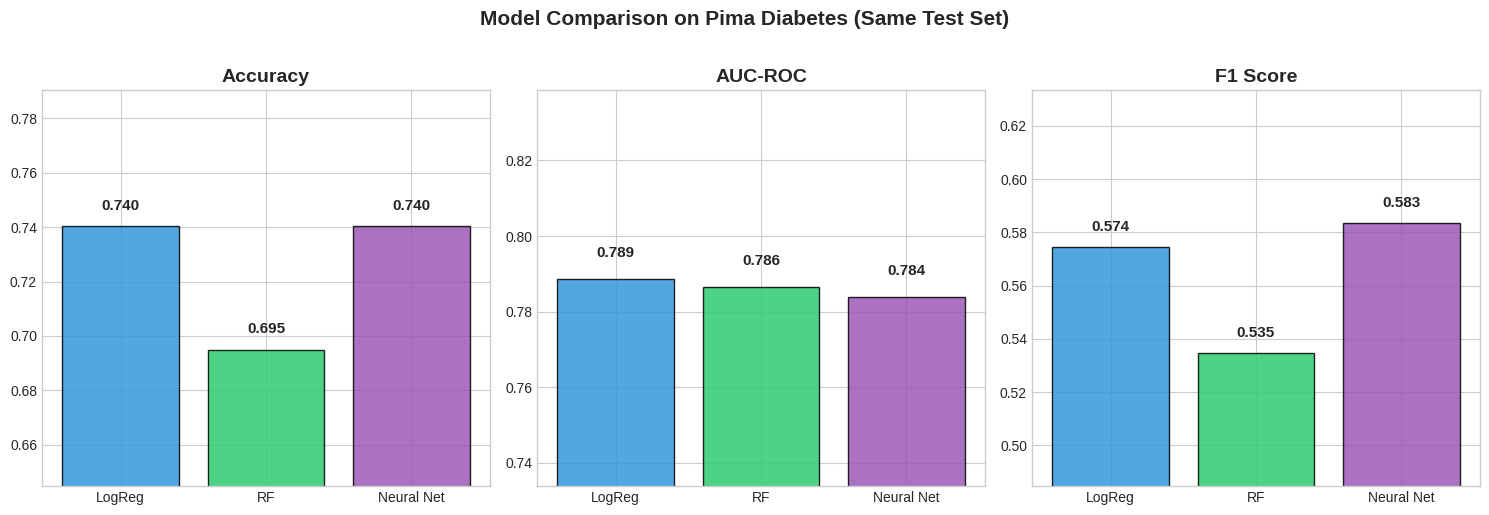

In [23]:
# --- Visual comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = ['LogReg', 'RF', 'Neural Net']
colors = ['#3498DB', '#2ECC71', '#9B59B6']

for metric, ax in zip(['Accuracy', 'AUC-ROC', 'F1 Score'], axes):
    values = results_df[metric].values
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(min(values) - 0.05, max(values) + 0.05)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Model Comparison on Pima Diabetes (Same Test Set)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# --- Detailed reports ---
print("\n" + "=" * 65)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 65)

for name, y_pred in [('Logistic Regression', y_pred_lr),
                      ('Random Forest', y_pred_rf),
                      ('Neural Network', y_pred_nn)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))


DETAILED CLASSIFICATION REPORTS

--- Logistic Regression ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       101
    Diabetes       0.66      0.51      0.57        53

    accuracy                           0.74       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.74      0.73       154


--- Random Forest ---
              precision    recall  f1-score   support

 No Diabetes       0.75      0.79      0.77       101
    Diabetes       0.56      0.51      0.53        53

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


--- Neural Network ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.85      0.81       101
    Diabetes       0.65      0.53      0.58        53

    accuracy                           0.74       154
   macro avg       

In [25]:
# --- Honest clinical assessment ---
acc_diff = abs(results_df['Accuracy'].max() - results_df['Accuracy'].min()) * 100

print("\n" + "=" * 65)
print("🏥 CLINICAL REALITY CHECK")
print("=" * 65)
print(f"\n   Accuracy range across 3 models: {acc_diff:.1f} percentage points")
print(f"   AUC range: {abs(results_df['AUC-ROC'].max() - results_df['AUC-ROC'].min()):.4f}")
print("")
if acc_diff < 3:
    print("   💡 The difference is <3% — NOT clinically significant!")
print("")
print("   On small tabular data (768 patients, 8 features):")
print("   • LogReg: fast, interpretable, works great")
print("   • RF: robust, handles non-linearity, feature importance")
print("   • NN: most flexible, but needs more data to shine")
print("")
print("   When neural networks DO dominate:")
print("   • Images: CheXNet AUC 0.97 (Week 8)")
print("   • Signals: ECG arrhythmia detection (Week 5-6)")
print("   • Text: Clinical NLP with Transformers (Week 13-14)")
print("")
print("   → The right model depends on the DATA, not the hype.")


🏥 CLINICAL REALITY CHECK

   Accuracy range across 3 models: 4.5 percentage points
   AUC range: 0.0047


   On small tabular data (768 patients, 8 features):
   • LogReg: fast, interpretable, works great
   • RF: robust, handles non-linearity, feature importance
   • NN: most flexible, but needs more data to shine

   When neural networks DO dominate:
   • Images: CheXNet AUC 0.97 (Week 8)
   • Signals: ECG arrhythmia detection (Week 5-6)
   • Text: Clinical NLP with Transformers (Week 13-14)

   → The right model depends on the DATA, not the hype.


---
## 10. ✅ Summary & Self-Check

### Key Takeaways

1. **Single neuron** = weighted sum + bias + activation: `a = g(w·x + b)`
2. **MLP** = stack neurons into layers: Input → Hidden(s) → Output
3. **Activation functions**: ReLU for hidden layers, Sigmoid for binary output, Softmax for multi-class
4. **Training loop**: forward pass → compute loss → backpropagation → update weights
5. **Regularization**: Dropout + EarlyStopping prevent overfitting
6. **Training curves** are your diagnostic tool: watch for val_loss divergence
7. **Honest truth**: On small tabular data, NN barely beats LogReg. The power comes with unstructured data.

### Self-Check Checklist

- [ ] I can compute a single neuron's output by hand (weighted sum + sigmoid)
- [ ] I can build a Keras Sequential model with Dense, Dropout, and compile it
- [ ] I can read training curves and diagnose overfitting vs underfitting
- [ ] I understand why EarlyStopping and Dropout are important
- [ ] I can compare NN vs LogReg vs RF and interpret the results honestly
- [ ] I used (or attempted to use) Gemini AI for debugging/explanation

### Next Week Preview
**Week 4: Supervised Learning Practical**
- Today you trained on a relatively clean dataset
- Next week: real hospital data with missing values, 99:1 class imbalance, duplicate records
- Skills you'll need: preprocessing pipelines, SMOTE, cross-validation

In [26]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 60)
print("🎉 Congratulations! You've completed Week 3 Notebook!")
print("=" * 60)
print(f"\n📊 Summary of your results:")
print(f"   Dataset: {len(df)} patients, 8 features (Pima Diabetes)")
print(f"   Neural Network Accuracy: {test_acc:.3f}")
print(f"   Neural Network AUC-ROC:  {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"   Training stopped at epoch: {len(history.history['loss'])}")
print(f"\n🔑 Key skills you practiced:")
print(f"   • Built a neuron from scratch in NumPy")
print(f"   • Built the same neuron in Keras (3 lines!)")
print(f"   • Visualized activation functions and their gradients")
print(f"   • Preprocessed real medical data (Pima diabetes)")
print(f"   • Trained a 3-layer MLP with Dropout + EarlyStopping")
print(f"   • Read and interpreted training curves")
print(f"   • Compared NN vs LogReg vs RF (honest assessment)")
print(f"\n📅 Next week: Supervised Learning with messy hospital data!")
print(f"   → Review training curves (Section 6) before Week 4")

🎉 Congratulations! You've completed Week 3 Notebook!

📊 Summary of your results:
   Dataset: 768 patients, 8 features (Pima Diabetes)
   Neural Network Accuracy: 0.740
   Neural Network AUC-ROC:  0.784
   Training stopped at epoch: 21

🔑 Key skills you practiced:
   • Built a neuron from scratch in NumPy
   • Built the same neuron in Keras (3 lines!)
   • Visualized activation functions and their gradients
   • Preprocessed real medical data (Pima diabetes)
   • Trained a 3-layer MLP with Dropout + EarlyStopping
   • Read and interpreted training curves
   • Compared NN vs LogReg vs RF (honest assessment)

📅 Next week: Supervised Learning with messy hospital data!
   → Review training curves (Section 6) before Week 4
